# 02 — Baseline econométrico sobre dataset real

## Release v1.0.0 — Scouting Intelligence Platform

## Objetivo del notebook

Este notebook construye un baseline econométrico reproducible para estimar el valor de mercado esperado de jugadores jóvenes en el fútbol europeo.

El notebook utiliza el dataset real construido tras el pipeline de integración multi-fuente:

```text
data/processed/player_season_modeling.parquet
```

En la release v1.0.0, este dataset contiene:

- 3.916 observaciones jugador–temporada
- 2.136 jugadores únicos
- Temporadas 2019-2020 a 2025-2026
- 7 ligas europeas
- Variables de rendimiento FBref
- Valor de mercado Transfermarkt
- Variables de calidad del matching

## Enfoque metodológico

Se comparan progresivamente varios modelos:

1. **M0 — Baseline ingenuo**: predice la media del target en train.
2. **M1 — OLS simple**: edad, minutos, goles y asistencias.
3. **M2 — OLS + League Fixed Effects**.
4. **M3 — OLS + League + Season + Position Fixed Effects**.

## Decisión Sprint 10

A partir de Sprint 10.3 se separan explícitamente dos capas:

```text
Historical Evaluation Layer
↓
Current Scouting Layer
```

Por tanto:

- Las temporadas **2019-2020 → 2023-2024** se utilizan como entrenamiento histórico.
- La temporada **2024-2025** se utiliza como test temporal out-of-sample.
- La temporada **2025-2026** se reserva para scouting operativo y no debe utilizarse para validar este baseline econométrico.

Esta separación evita mezclar validación histórica con recomendaciones actuales de mercado.


## 1. Imports y configuración

In [20]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ROOT = Path.cwd()

# Si el notebook se ejecuta desde /notebooks, subir un nivel
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_PATH = ROOT / "data" / "processed" / "player_season_modeling.parquet"
OUTPUT_DIR = ROOT / "reports" / "tables"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TARGET = "log_market_value_eur"

TRAIN_SEASONS = [
    "2019-2020",
    "2020-2021",
    "2021-2022",
    "2022-2023",
    "2023-2024",
]

TEST_SEASON = "2024-2025"
CURRENT_SCOUTING_SEASON = "2025-2026"

BASE_FEATURES = [
    "age",
    "log_minutes_played",
    "goals_per90",
    "assists_per90",
]

CATEGORICAL_FE = [
    "league",
    "season",
    "position_group",
]


## 2. Carga del dataset real

La celda siguiente valida que el notebook trabaja sobre el dataset correcto (`player_season_modeling.parquet`) y no sobre artefactos intermedios o residuales.

In [21]:
df = pd.read_parquet(DATA_PATH)

print(f"Dataset path: {DATA_PATH}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns):,}")

display(df.head())

Dataset path: c:\Users\manue\Projects\market-value-football-tfm\data\processed\player_season_modeling.parquet
Rows: 3,916
Columns: 54


,player_name_fbref,club,league,season,season_start_year_fbref,position,position_group,age_fbref,matches_played,starts,minutes_played,nineties,goals,assists,g_a,goals_minus_pk,penalties_scored,penalties_attempted,yellow_cards,red_cards,goals_per90,assists_per90,g_a_per90,goals_minus_pk_per90,g_a_minus_pk_per90,player_name_norm,player_id_tm,player_name_tm,season_start_year_tm,valuation_date,market_value_eur,log_market_value_eur,market_value_prev_eur,market_value_next_eur,market_value_growth_1y,delta_log_market_value_1y,age_tm,date_of_birth,nationality,position_tm,sub_position_tm,foot,height_in_cm,current_club_name_tm,current_club_id_tm,competition_id_tm,source,matching_method,matching_confidence,age_diff,club_score,matching_status,season_start_year,age
0,Marvin Young,Sparta Rotterdam,Eredivisie,2025-2026,2025,DF,DEF,19.0000,33,33,2970,33.0000,0,1,1,0,0,0,7,0,0.0000,0.0300,0.0300,0.0000,0.0300,marvin young,"928,592.0000",Marvin Young,"2,025.0000",2025-10-02,"4,000,000.0000",15.2018,"2,500,000.0000","4,000,000.0000",0.0000,0.0000,20.0000,2005-10-02 00:00:00,Netherlands,Defender,Centre-Back,right,182.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.0000,100.0000,True,2025,20.0000
1,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2022-2023,2022,MF,MID,20.0000,34,29,2651,29.5000,4,2,6,4,0,0,2,0,0.1400,0.0700,0.2000,0.1400,0.2000,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,022.0000",2022-11-11,"1,200,000.0000",13.9978,"800,000.0000","3,000,000.0000",1.5000,0.9163,21.2731,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2731,100.0000,True,2022,21.2731
2,Teden Mengi,Luton Town,Premier League,2023-2024,2023,DF,DEF,21.0000,30,28,2469,27.4000,1,0,1,1,0,0,3,0,0.0400,0.0000,0.0400,0.0400,0.0400,teden mengi,"548,470.0000",Teden Mengi,"2,023.0000",2023-12-19,"7,000,000.0000",15.7614,"2,000,000.0000","12,000,000.0000",0.7143,0.5390,21.6372,2002-04-30 00:00:00,England,Defender,Centre-Back,right,186.0000,Luton Town,"1,031.0000",GB1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,0.6372,100.0000,True,2023,21.6372
3,Shurandy Sambo,Sparta Rotterdam,Eredivisie,2022-2023,2022,DF,DEF,20.0000,30,28,2307,25.6000,2,1,3,2,0,0,4,2,0.0800,0.0400,0.1200,0.0800,0.1200,shurandy sambo,"412,937.0000",Shurandy Sambo,"2,022.0000",2022-11-11,"700,000.0000",13.4588,"500,000.0000","3,000,000.0000",3.2857,1.4553,21.2293,2001-08-19 00:00:00,Curacao,Defender,Right-Back,right,174.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.2293,100.0000,True,2022,21.2293
4,Joshua Kitolano,Sparta Rotterdam,Eredivisie,2023-2024,2023,MF,MID,21.0000,24,24,2106,23.4000,5,2,7,3,2,2,2,0,0.2100,0.0900,0.3000,0.1300,0.2100,joshua kitolano,"432,694.0000",Joshua Kitolano,"2,023.0000",2023-12-15,"4,500,000.0000",15.3196,"4,500,000.0000","4,500,000.0000",0.0000,0.0000,22.3655,2001-08-03 00:00:00,Norway,Midfield,Defensive Midfield,right,170.0000,Sparta Rotterdam,468.0000,NL1,transfermarkt_kaggle_player_scores,exact_age_club_validated,1.0000,1.3655,100.0000,True,2023,22.3655


## 3. Validación mínima de estructura

Se verifica la existencia de las columnas necesarias para el baseline econométrico.

In [22]:
required_cols = [
    TARGET,
    "market_value_eur",
    "age",
    "minutes_played",
    "goals_per90",
    "assists_per90",
    "league",
    "season",
    "position_group",
    "matching_method",
    "matching_confidence",
    "age_diff",
    "club_score",
]

missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise KeyError(f"Missing required columns: {missing_cols}")

print("All required columns are present.")

All required columns are present.


## 4. Preparación de muestra econométrica

Se construye una copia específica para modelización:

- Se eliminan nulos en variables esenciales.
- Se fuerza tipo numérico.
- Se crea `log_minutes_played = log(1 + minutes_played)` para reducir la asimetría de minutos.
- Se eliminan observaciones sin liga, temporada o posición.

In [23]:
model_df = df.copy()

numeric_cols = [
    TARGET,
    "market_value_eur",
    "age",
    "minutes_played",
    "goals_per90",
    "assists_per90",
    "matching_confidence",
    "age_diff",
    "club_score",
]

for col in numeric_cols:
    model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

model_df["log_minutes_played"] = np.log1p(model_df["minutes_played"])

essential_cols = [
    TARGET,
    "market_value_eur",
    "age",
    "minutes_played",
    "log_minutes_played",
    "goals_per90",
    "assists_per90",
    "league",
    "season",
    "position_group",
]

model_df = model_df.dropna(subset=essential_cols).copy()

# Evitar valores imposibles
model_df = model_df[model_df["market_value_eur"] > 0].copy()
model_df = model_df[model_df["minutes_played"] > 0].copy()

print(f"Rows after econometric preparation: {len(model_df):,}")
print(f"Players: {model_df['player_name_fbref'].nunique() if 'player_name_fbref' in model_df.columns else 'N/A'}")
print(f"Seasons: {model_df['season'].min()} - {model_df['season'].max()}")

display(model_df[[
    "season", "league", "position_group", "age", "minutes_played",
    "goals_per90", "assists_per90", "market_value_eur", TARGET,
    "matching_method", "matching_confidence"
]].head())

Rows after econometric preparation: 3,916
Players: 2136
Seasons: 2019-2020 - 2025-2026


,season,league,position_group,age,minutes_played,goals_per90,assists_per90,market_value_eur,log_market_value_eur,matching_method,matching_confidence
0,2025-2026,Eredivisie,DEF,20.0000,2970,0.0000,0.0300,"4,000,000.0000",15.2018,exact_age_club_validated,1.0000
1,2022-2023,Eredivisie,MID,21.2731,2651,0.1400,0.0700,"1,200,000.0000",13.9978,exact_age_club_validated,1.0000
2,2023-2024,Premier League,DEF,21.6372,2469,0.0400,0.0000,"7,000,000.0000",15.7614,exact_age_club_validated,1.0000
3,2022-2023,Eredivisie,DEF,21.2293,2307,0.0800,0.0400,"700,000.0000",13.4588,exact_age_club_validated,1.0000
4,2023-2024,Eredivisie,MID,22.3655,2106,0.2100,0.0900,"4,500,000.0000",15.3196,exact_age_club_validated,1.0000


## 5. Descripción de la muestra

Este bloque resume la cobertura final antes de la división temporal.

In [24]:
print("Rows by season:")
display(model_df["season"].value_counts().sort_index())

print("\nRows by league:")
display(model_df["league"].value_counts())

print("\nRows by position group:")
display(model_df["position_group"].value_counts())

print("\nMatching methods:")
display(model_df["matching_method"].value_counts(dropna=False))

print("\nNumeric summary:")
display(model_df[[
    "age",
    "minutes_played",
    "log_minutes_played",
    "goals_per90",
    "assists_per90",
    "market_value_eur",
    TARGET,
    "matching_confidence",
    "age_diff",
    "club_score",
]].describe())

Rows by season:


season
2019-2020    537
2020-2021    536
2021-2022    544
2022-2023    542
2023-2024    586
2024-2025    552
2025-2026    619
Name: count, dtype: int64


Rows by league:


league
Ligue 1           731
Eredivisie        660
Serie A           578
Premier League    545
Bundesliga        529
LaLiga            453
Liga Portugal     420
Name: count, dtype: int64


Rows by position group:


position_group
MID    2042
DEF    1358
ATT     407
GK      109
Name: count, dtype: int64


Matching methods:


matching_method
exact_age_validated         3673
exact_age_club_validated     239
fuzzy_age_club_validated       4
Name: count, dtype: int64


Numeric summary:


,age,minutes_played,log_minutes_played,goals_per90,assists_per90,market_value_eur,log_market_value_eur,matching_confidence,age_diff,club_score
count,"3,916.0000","3,916.0000","3,916.0000","3,916.0000","3,916.0000","3,916.0000","3,916.0000","3,916.0000","3,916.0000","3,916.0000"
mean,21.3223,"1,439.2214",7.1002,0.1367,0.0968,"11,769,081.9714",15.4765,0.8593,0.7252,34.8492
std,1.2269,777.2311,0.6218,0.1826,0.1161,"17,684,378.1382",1.3149,0.0360,0.2975,20.3000
min,18.0068,300.0000,5.7071,0.0000,0.0000,"500,000.0000",13.1224,0.8500,0.0014,0.0000
25%,20.4867,756.7500,6.6304,0.0000,0.0000,"2,000,000.0000",14.5087,0.8500,0.5031,19.5122
50%,21.5606,"1,346.5000",7.2060,0.0700,0.0600,"5,500,000.0000",15.5203,0.8500,0.7201,28.5714
75%,22.3682,"2,037.0000",7.6197,0.2000,0.1525,"15,000,000.0000",16.5236,0.8500,0.9329,50.0000
max,22.9979,"3,420.0000",8.1377,1.9000,0.9400,"200,000,000.0000",19.1138,1.0000,1.4997,100.0000


## 6. División temporal y separación Sprint 10

La validación temporal es más exigente y más realista que una división aleatoria.

Configuración de release v1.0.0:

- **Train histórico:** 2019-2020 → 2023-2024.
- **Test temporal:** 2024-2025.
- **Current Scouting Layer:** 2025-2026.

La temporada 2025-2026 queda explícitamente excluida del entrenamiento y del test de este notebook porque pertenece a la capa operativa de scouting actual.

Esta estrategia permite mantener una separación metodológica clara entre:

```text
evaluación histórica
y
recomendación operativa actual
```


In [25]:
train = model_df[model_df["season"].isin(TRAIN_SEASONS)].copy()
test = model_df[model_df["season"] == TEST_SEASON].copy()
current_scouting = model_df[model_df["season"] == CURRENT_SCOUTING_SEASON].copy()

if train.empty:
    raise ValueError("Train set is empty. Check season labels.")

if test.empty:
    raise ValueError("Test set is empty. Check TEST_SEASON.")

print(f"Train rows: {len(train):,}")
print(f"Test rows: {len(test):,}")
print(f"Current scouting rows: {len(current_scouting):,}")

print("\nTrain seasons:")
display(train["season"].value_counts().sort_index())

print("\nTest seasons:")
display(test["season"].value_counts().sort_index())

print("\nCurrent scouting season:")
display(current_scouting["season"].value_counts().sort_index())


Train rows: 2,745
Test rows: 552
Current scouting rows: 619

Train seasons:


season
2019-2020    537
2020-2021    536
2021-2022    544
2022-2023    542
2023-2024    586
Name: count, dtype: int64


Test seasons:


season
2024-2025    552
Name: count, dtype: int64


Current scouting season:


season
2025-2026    619
Name: count, dtype: int64

## 6.1 Implicación metodológica de la separación temporal

El baseline econométrico de este notebook pertenece a la **Historical Evaluation Layer**.

Su función es:

- construir un benchmark interpretable;
- validar la capacidad explicativa de variables deportivas básicas;
- analizar efectos estructurales por liga, temporada y posición;
- generar una primera lectura econométrica del mercado.

No debe utilizarse directamente como ranking operativo de scouting actual. Para ello, la release v1.0.0 utiliza el pipeline productivo basado en Tuned XGBoost, Scoring Engine, Risk Framework y Current Scouting Layer.


## 7. Funciones auxiliares

Se definen funciones para:

- Construir matrices de diseño.
- Ajustar OLS con errores robustos HC3.
- Calcular métricas compatibles con distintas versiones de scikit-learn.

In [26]:
def build_design_matrix(data: pd.DataFrame, base_features, categorical_features=None):
    X = data[base_features].copy()

    if categorical_features:
        dummies = pd.get_dummies(
            data[categorical_features],
            drop_first=True,
            dtype=float,
        )
        X = pd.concat([X, dummies], axis=1)

    X = X.astype(float)
    X = sm.add_constant(X, has_constant="add")

    return X


def fit_ols_hc3(train_data: pd.DataFrame, base_features, categorical_features=None):
    y = train_data[TARGET].astype(float)
    X = build_design_matrix(train_data, base_features, categorical_features)

    model = sm.OLS(y, X)
    fitted = model.fit(cov_type="HC3")

    return fitted, X.columns.tolist()


def align_test_matrix(test_data: pd.DataFrame, train_columns, base_features, categorical_features=None):
    X_test = build_design_matrix(test_data, base_features, categorical_features)

    X_test = X_test.reindex(columns=train_columns, fill_value=0.0)
    X_test = X_test.astype(float)

    return X_test


def regression_metrics(y_true, y_pred, label):
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)

    return {
        "model": label,
        "MAE_log": mean_absolute_error(y_true, y_pred),
        "RMSE_log": rmse,
        "R2": r2_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else np.nan,
    }

## 8. Modelos baseline

Se estiman cuatro modelos progresivos.

### M0 — Media del target

Sirve como referencia mínima: cualquier modelo útil debe mejorar este benchmark.

### M1 — OLS simple

Incluye:

```text
age
log_minutes_played
goals_per90
assists_per90
```

### M2 — OLS + League Fixed Effects

Añade efectos estructurales por competición.

### M3 — OLS + League + Season + Position Fixed Effects

Modelo econométrico completo del notebook.

Nota metodológica:

Aunque Sprint 10.3 incorpora 2025-2026 al dataset global, esta temporada se reserva para la capa operativa de scouting y no forma parte del baseline histórico de este notebook.


In [27]:
models = {}

# M0: Mean baseline
train_mean = train[TARGET].mean()
m0_pred_train = np.repeat(train_mean, len(train))
m0_pred_test = np.repeat(train_mean, len(test))

# M1
m1, m1_cols = fit_ols_hc3(
    train,
    base_features=BASE_FEATURES,
    categorical_features=None,
)
models["M1_OLS_simple"] = (m1, m1_cols, None)

# M2
m2, m2_cols = fit_ols_hc3(
    train,
    base_features=BASE_FEATURES,
    categorical_features=["league"],
)
models["M2_OLS_league_FE"] = (m2, m2_cols, ["league"])

# M3
m3, m3_cols = fit_ols_hc3(
    train,
    base_features=BASE_FEATURES,
    categorical_features=CATEGORICAL_FE,
)
models["M3_OLS_full_FE"] = (m3, m3_cols, CATEGORICAL_FE)

print("Models fitted:")
for name in models:
    print("-", name)

Models fitted:
- M1_OLS_simple
- M2_OLS_league_FE
- M3_OLS_full_FE


## 9. Comparación de métricas

Se comparan métricas en train y test para detectar:

- Capacidad explicativa.
- Generalización temporal.
- Posible sobreajuste.

In [28]:
results = []

results.append({
    **regression_metrics(train[TARGET], m0_pred_train, "M0_mean_train"),
    "sample": "train",
})
results.append({
    **regression_metrics(test[TARGET], m0_pred_test, "M0_mean_test"),
    "sample": "test",
})

for name, (fitted, train_cols, cats) in models.items():
    # Train
    X_train = build_design_matrix(train, BASE_FEATURES, cats)
    X_train = X_train.reindex(columns=train_cols, fill_value=0.0)
    pred_train = fitted.predict(X_train)

    results.append({
        **regression_metrics(train[TARGET], pred_train, f"{name}_train"),
        "sample": "train",
    })

    # Test
    X_test = align_test_matrix(test, train_cols, BASE_FEATURES, cats)
    pred_test = fitted.predict(X_test)

    results.append({
        **regression_metrics(test[TARGET], pred_test, f"{name}_test"),
        "sample": "test",
    })

metrics_df = pd.DataFrame(results)
metrics_df = metrics_df[["model", "sample", "MAE_log", "RMSE_log", "R2"]]

display(metrics_df)

metrics_df.to_csv(OUTPUT_DIR / "02_baseline_model_metrics.csv", index=False)

,model,sample,MAE_log,RMSE_log,R2
0,M0_mean_train,train,1.0960,1.3117,0.0000
1,M0_mean_test,test,1.0899,1.3212,-0.0059
2,M1_OLS_simple_train,train,1.0146,1.2186,0.1369
3,M1_OLS_simple_test,test,1.0036,1.2165,0.1472
4,M2_OLS_league_FE_train,train,0.8199,1.0100,0.4071
5,M2_OLS_league_FE_test,test,0.7954,0.9896,0.4356
6,M3_OLS_full_FE_train,train,0.8191,1.0082,0.4093
7,M3_OLS_full_FE_test,test,0.7907,0.9823,0.4439


## 10. Resumen del modelo completo

Se muestra el resumen de M3, que incorpora efectos fijos por liga, temporada y posición.

In [29]:
m3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                             OLS Regression Results                             
================================================================================
Dep. Variable:     log_market_value_eur   R-squared:                       0.409
Model:                              OLS   Adj. R-squared:                  0.406
Method:                   Least Squares   F-statistic:                     130.3
Date:                  Tue, 02 Jun 2026   Prob (F-statistic):               0.00
Time:                          22:36:22   Log-Likelihood:                -3917.4
No. Observations:                  2745   AIC:                             7871.
Df Residuals:                      2727   BIC:                             7977.
Df Model:                            17                                         
Covariance Type:                    HC3                                         
=========================================================================================
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                    10.7631      0.401     26.823      0.000       9.977      11.550
age                       0.0397      0.017      2.333      0.020       0.006       0.073
log_minutes_played        0.5481      0.033     16.613      0.000       0.483       0.613
goals_per90               1.4129      0.130     10.888      0.000       1.159       1.667
assists_per90             1.7832      0.183      9.726      0.000       1.424       2.143
league_Eredivisie        -1.4466      0.072    -20.142      0.000      -1.587      -1.306
league_LaLiga             0.0654      0.084      0.781      0.435      -0.099       0.230
league_Liga Portugal     -1.1222      0.083    -13.575      0.000      -1.284      -0.960
league_Ligue 1           -0.3363      0.071     -4.747      0.000      -0.475      -0.197
league_Premier League     0.7110      0.071     10.084      0.000       0.573       0.849
league_Serie A           -0.1456      0.073     -1.982      0.047      -0.290      -0.002
season_2020-2021         -0.1620      0.064     -2.547      0.011      -0.287      -0.037
season_2021-2022         -0.1222      0.062     -1.977      0.048      -0.243      -0.001
season_2022-2023         -0.1163      0.061     -1.906      0.057      -0.236       0.003
season_2023-2024         -0.1488      0.061     -2.457      0.014      -0.268      -0.030
position_group_DEF        0.0339      0.079      0.428      0.668      -0.121       0.189
position_group_GK        -0.0692      0.132     -0.523      0.601      -0.328       0.190
position_group_MID       -0.0001      0.071     -0.002      0.998      -0.139       0.139
==============================================================================
Omnibus:                       13.321   Durbin-Watson:                   1.719
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               10.213
Skew:                           0.041   Prob(JB):                      0.00606
Kurtosis:                       2.713   Cond. No.                         452.
==============================================================================

Notes:
[1] Standard Errors are heteroscedasticity robust (HC3)
"""

## 11. Tabla de coeficientes interpretables

Para facilitar la lectura, se extraen coeficientes, errores robustos HC3, estadísticos t, p-values e intervalos de confianza.

In [30]:
def coefficient_table(fitted):
    conf = fitted.conf_int()
    table = pd.DataFrame({
        "term": fitted.params.index,
        "coef": fitted.params.values,
        "std_err_HC3": fitted.bse.values,
        "t_value": fitted.tvalues.values,
        "p_value": fitted.pvalues.values,
        "ci_lower": conf[0].values,
        "ci_upper": conf[1].values,
    })

    table["approx_pct_effect"] = (np.exp(table["coef"]) - 1) * 100

    return table.sort_values("p_value")

coef_table = coefficient_table(m3)

display(coef_table)

coef_table.to_csv(OUTPUT_DIR / "02_baseline_coefficient_table.csv", index=False)

,term,coef,std_err_HC3,t_value,p_value,ci_lower,ci_upper,approx_pct_effect
0,const,10.7631,0.4013,26.8233,0.0000,9.9767,11.5496,"4,724,470.4565"
5,league_Eredivisie,-1.4466,0.0718,-20.1416,0.0000,-1.5874,-1.3058,-76.4633
2,log_minutes_played,0.5481,0.0330,16.6126,0.0000,0.4834,0.6128,72.9961
7,league_Liga Portugal,-1.1222,0.0827,-13.5746,0.0000,-1.2842,-0.9602,-67.4436
3,goals_per90,1.4129,0.1298,10.8878,0.0000,1.1586,1.6673,310.7940
9,league_Premier League,0.7110,0.0705,10.0843,0.0000,0.5728,0.8491,103.5955
4,assists_per90,1.7832,0.1833,9.7258,0.0000,1.4238,2.1425,494.8767
8,league_Ligue 1,-0.3363,0.0708,-4.7470,0.0000,-0.4752,-0.1975,-28.5595
11,season_2020-2021,-0.1620,0.0636,-2.5470,0.0109,-0.2866,-0.0373,-14.9533
14,season_2023-2024,-0.1488,0.0606,-2.4571,0.0140,-0.2676,-0.0301,-13.8300


## 12. Coeficientes principales

Se aíslan las variables base para interpretación económica.

In [31]:
main_terms = ["age", "log_minutes_played", "goals_per90", "assists_per90"]

main_coef = coef_table[coef_table["term"].isin(main_terms)].copy()
display(main_coef.sort_values("term"))

,term,coef,std_err_HC3,t_value,p_value,ci_lower,ci_upper,approx_pct_effect
1,age,0.0397,0.0170,2.3334,0.0196,0.0064,0.0731,4.0537
4,assists_per90,1.7832,0.1833,9.7258,0.0000,1.4238,2.1425,494.8767
3,goals_per90,1.4129,0.1298,10.8878,0.0000,1.1586,1.6673,310.7940
2,log_minutes_played,0.5481,0.0330,16.6126,0.0000,0.4834,0.6128,72.9961


## 13. Diagnóstico de multicolinealidad

El VIF se calcula sobre la matriz de diseño del modelo completo.

Interpretación orientativa:

- VIF < 5: aceptable
- 5–10: revisar
- >10: posible multicolinealidad relevante

In [32]:
X_vif = build_design_matrix(train, BASE_FEATURES, CATEGORICAL_FE)

# Eliminar constante para VIF
X_vif_no_const = X_vif.drop(columns=["const"], errors="ignore")

vif_rows = []

for i, col in enumerate(X_vif_no_const.columns):
    try:
        vif = variance_inflation_factor(X_vif_no_const.values, i)
    except Exception:
        vif = np.nan

    vif_rows.append({
        "feature": col,
        "VIF": vif,
    })

vif_df = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)

display(vif_df)

vif_df.to_csv(OUTPUT_DIR / "02_baseline_vif_table.csv", index=False)

,feature,VIF
1,log_minutes_played,122.9711
0,age,120.9724
16,position_group_MID,6.6618
14,position_group_DEF,5.7381
7,league_Ligue 1,2.4516
4,league_Eredivisie,2.2792
2,goals_per90,2.2690
9,league_Serie A,2.1636
13,season_2023-2024,2.0864
8,league_Premier League,2.0823


## 14. Predicción out-of-sample y residuos

Se calculan predicciones sobre test y residuos:

- Residuo clásico: observado - predicho.
- Inefficiency Score exploratorio: predicho - observado.

En este notebook el score es exploratorio. La versión final se construirá en el notebook econométrico final.

In [33]:
best_model = m3
best_cols = m3_cols
best_cats = CATEGORICAL_FE

X_test = align_test_matrix(test, best_cols, BASE_FEATURES, best_cats)
test_pred = best_model.predict(X_test)

test_results = test.copy()
test_results["predicted_log_market_value"] = test_pred
test_results["predicted_market_value_eur"] = np.exp(test_results["predicted_log_market_value"])

test_results["residual_observed_minus_predicted"] = (
    test_results[TARGET] - test_results["predicted_log_market_value"]
)

test_results["inefficiency_score"] = (
    test_results["predicted_log_market_value"] - test_results[TARGET]
)

test_results["market_value_gap_eur"] = (
    test_results["predicted_market_value_eur"] - test_results["market_value_eur"]
)

test_results["market_value_gap_pct"] = (
    test_results["market_value_gap_eur"] / test_results["market_value_eur"]
)

test_results["inefficiency_score_z"] = (
    (test_results["inefficiency_score"] - test_results["inefficiency_score"].mean())
    / test_results["inefficiency_score"].std(ddof=0)
)

# Score exploratorio ajustado por matching
test_results["confidence_score"] = test_results["matching_confidence"].fillna(0.85)
test_results["opportunity_score"] = (
    test_results["inefficiency_score_z"] * test_results["confidence_score"]
)

display(test_results[[
    TARGET,
    "predicted_log_market_value",
    "residual_observed_minus_predicted",
    "inefficiency_score",
    "market_value_eur",
    "predicted_market_value_eur",
    "market_value_gap_eur",
    "market_value_gap_pct",
    "matching_method",
    "matching_confidence",
]].head())

test_results.to_parquet(OUTPUT_DIR / "02_baseline_test_predictions.parquet", index=False)

,log_market_value_eur,predicted_log_market_value,residual_observed_minus_predicted,inefficiency_score,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,matching_method,matching_confidence
5,14.2210,15.3435,-1.1225,1.1225,"1,500,000.0000","4,608,740.1257","3,108,740.1257",2.0725,exact_age_club_validated,1.0000
6,14.0779,14.4292,-0.3514,0.3514,"1,300,000.0000","1,847,305.4638","547,305.4638",0.4210,exact_age_club_validated,1.0000
11,13.1224,16.0814,-2.9591,2.9591,"500,000.0000","9,640,147.6637","9,140,147.6637",18.2803,exact_age_club_validated,1.0000
13,13.3847,14.6279,-1.2432,1.2432,"650,000.0000","2,253,337.0002","1,603,337.0002",2.4667,exact_age_club_validated,1.0000
21,13.8155,14.2042,-0.3887,0.3887,"1,000,000.0000","1,475,089.4760","475,089.4760",0.4751,exact_age_club_validated,1.0000


## 15. Visualización: observado vs predicho

El gráfico permite evaluar visualmente si el modelo captura razonablemente la escala del valor de mercado.

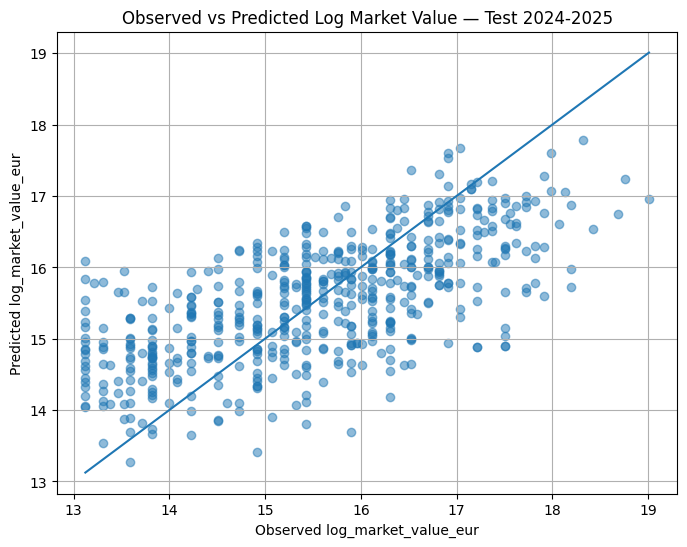

In [34]:
plt.figure(figsize=(8, 6))
plt.scatter(
    test_results[TARGET],
    test_results["predicted_log_market_value"],
    alpha=0.5,
)

min_val = min(test_results[TARGET].min(), test_results["predicted_log_market_value"].min())
max_val = max(test_results[TARGET].max(), test_results["predicted_log_market_value"].max())

plt.plot([min_val, max_val], [min_val, max_val])
plt.xlabel("Observed log_market_value_eur")
plt.ylabel("Predicted log_market_value_eur")
plt.title("Observed vs Predicted Log Market Value — Test 2024-2025")
plt.grid(True)
plt.show()

## 16. Visualización: distribución de residuos

Un baseline razonable debería producir residuos centrados alrededor de cero, aunque es esperable dispersión en los extremos del mercado.

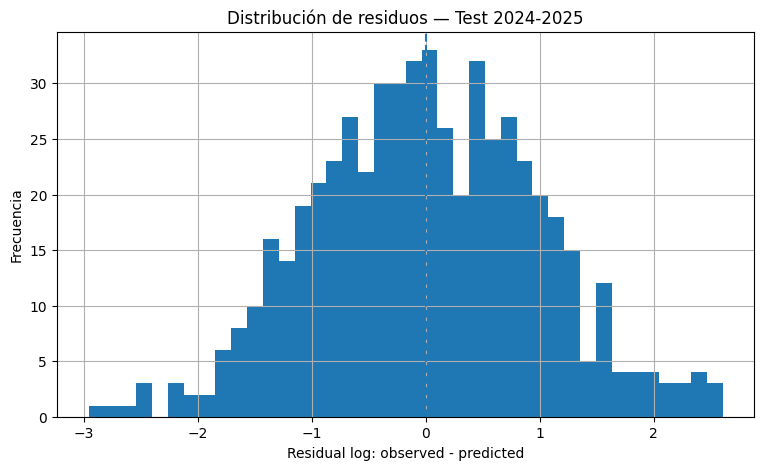

In [35]:
plt.figure(figsize=(9, 5))
plt.hist(test_results["residual_observed_minus_predicted"], bins=40)
plt.axvline(0, linestyle="--")
plt.xlabel("Residual log: observed - predicted")
plt.ylabel("Frecuencia")
plt.title("Distribución de residuos — Test 2024-2025")
plt.grid(True)
plt.show()

## 17. Visualización: residuos vs predicción

Se inspecciona si existe un patrón sistemático en los errores.

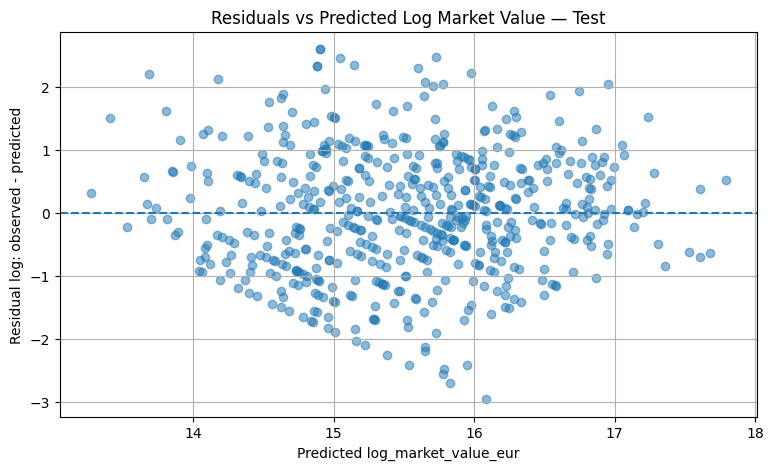

In [36]:
plt.figure(figsize=(9, 5))
plt.scatter(
    test_results["predicted_log_market_value"],
    test_results["residual_observed_minus_predicted"],
    alpha=0.5,
)
plt.axhline(0, linestyle="--")
plt.xlabel("Predicted log_market_value_eur")
plt.ylabel("Residual log: observed - predicted")
plt.title("Residuals vs Predicted Log Market Value — Test")
plt.grid(True)
plt.show()

## 18. Ranking exploratorio de infravaloración

Este ranking no debe interpretarse como una recomendación automática de fichaje.

Sirve como primera priorización cuantitativa sobre la temporada de test histórico 2024-2025 para comprobar si el baseline econométrico genera señales razonables de infravaloración.

En la release v1.0.0, las recomendaciones operativas reales se generan mediante:

```text
Tuned XGBoost
↓
Scoring Engine
↓
Risk Framework
↓
Current Scouting Layer
↓
scouting_shortlist_with_risk.csv
```

Por tanto, el ranking de este notebook tiene valor metodológico y exploratorio, no operativo.


In [37]:
ranking_cols = [
    "player_name_fbref",
    "club",
    "league",
    "season",
    "position_group",
    "age",
    "minutes_played",
    "market_value_eur",
    "predicted_market_value_eur",
    "market_value_gap_eur",
    "market_value_gap_pct",
    "inefficiency_score",
    "inefficiency_score_z",
    "matching_method",
    "matching_confidence",
    "age_diff",
    "club_score",
]

ranking_cols = [c for c in ranking_cols if c in test_results.columns]

undervalued = (
    test_results
    .sort_values("opportunity_score", ascending=False)
    [ranking_cols + ["opportunity_score"]]
    .head(25)
)

overvalued = (
    test_results
    .sort_values("opportunity_score", ascending=True)
    [ranking_cols + ["opportunity_score"]]
    .head(25)
)

print("Top undervalued exploratory ranking:")
display(undervalued)

print("\nTop overvalued exploratory ranking:")
display(overvalued)

undervalued.to_csv(OUTPUT_DIR / "02_baseline_undervalued_ranking.csv", index=False)
overvalued.to_csv(OUTPUT_DIR / "02_baseline_overvalued_ranking.csv", index=False)

Top undervalued exploratory ranking:


,player_name_fbref,club,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,inefficiency_score,inefficiency_score_z,matching_method,matching_confidence,age_diff,club_score,opportunity_score
11,Lasse Rosenboom,Holstein Kiel,Bundesliga,2024-2025,MID,22.9185,1734,"500,000.0000","9,640,147.6637","9,140,147.6637",18.2803,2.9591,3.0125,exact_age_club_validated,1.0000,0.9185,100.0000,3.0125
2804,Mario Martín,Valladolid,LaLiga,2024-2025,MID,20.6023,1748,"500,000.0000","7,487,716.8065","6,987,716.8065",13.9754,2.7064,2.7552,exact_age_validated,0.8500,0.6023,20.8333,2.3419
1702,Dominik Javorček,Holstein Kiel,Bundesliga,2024-2025,DEF,22.1328,386,"550,000.0000","7,134,293.5050","6,584,293.5050",11.9714,2.5628,2.6090,exact_age_validated,0.8500,1.1328,31.2500,2.2176
1200,Yan Diomandé,Leganés,LaLiga,2024-2025,MID,18.4723,545,"600,000.0000","7,176,285.5845","6,576,285.5845",10.9605,2.4816,2.5264,exact_age_validated,0.8500,1.4723,41.3793,2.1474
629,Johan Manzambi,Freiburg,Bundesliga,2024-2025,MID,18.9870,335,"750,000.0000","8,454,904.7159","7,704,904.7159",10.2732,2.4224,2.4661,exact_age_validated,0.8500,0.9870,59.2593,2.0962
1588,Yassin Belkhdim,Angers,Ligue 1,2024-2025,MID,22.6448,1523,"500,000.0000","5,583,610.4478","5,083,610.4478",10.1672,2.4130,2.4565,exact_age_validated,0.8500,0.6448,32.4324,2.0880
1013,Pau Navarro,Villarreal,LaLiga,2024-2025,DEF,19.6496,916,"500,000.0000","4,789,324.9691","4,289,324.9691",8.5786,2.2595,2.3003,exact_age_validated,0.8500,0.6496,48.7805,1.9553
3033,Jesus Rodríguez,Real Betis,LaLiga,2024-2025,MID,18.8966,1111,"700,000.0000","6,259,922.6766","5,559,922.6766",7.9427,2.1908,2.2304,exact_age_validated,0.8500,0.8966,19.0476,1.8958
645,Antoine Hainaut,Parma,Serie A,2024-2025,DEF,22.6639,1206,"750,000.0000","6,281,850.8195","5,531,850.8195",7.3758,2.1253,2.1637,exact_age_validated,0.8500,0.6639,58.8235,1.8391
1649,Kévin Danois,Auxerre,Ligue 1,2024-2025,MID,20.2765,1460,"500,000.0000","4,099,325.2251","3,599,325.2251",7.1987,2.1040,2.1419,exact_age_validated,0.8500,0.2765,31.8182,1.8206



Top overvalued exploratory ranking:


,player_name_fbref,club,league,season,position_group,age,minutes_played,market_value_eur,predicted_market_value_eur,market_value_gap_eur,market_value_gap_pct,inefficiency_score,inefficiency_score_z,matching_method,matching_confidence,age_diff,club_score,opportunity_score
181,Warren Zaïre-Emery,Paris Saint-Germain,Ligue 1,2024-2025,DEF,18.7598,2050,"60,000,000.0000","5,974,618.9352","-54,025,381.0648",-0.9004,-2.3068,-2.3483,exact_age_club_validated,1.0000,0.7598,73.0769,-2.3483
1023,António Silva,Benfica,Liga Portugal,2024-2025,DEF,20.9418,2037,"40,000,000.0000","2,959,009.5647","-37,040,990.4353",-0.9260,-2.6040,-2.6509,exact_age_validated,0.8500,0.9418,48.2759,-2.2532
568,Ousmane Diomande,Sporting CP,Liga Portugal,2024-2025,DEF,21.0431,2521,"40,000,000.0000","2,967,060.6726","-37,032,939.3274",-0.9258,-2.6013,-2.6481,exact_age_validated,0.8500,1.0431,59.4595,-2.2509
557,Gavi,Barcelona,LaLiga,2024-2025,MID,20.3943,1085,"80,000,000.0000","6,755,332.4395","-73,244,667.5605",-0.9156,-2.4717,-2.5162,exact_age_validated,0.8500,1.3943,60.0000,-2.1387
3372,Johan Bakayoko,PSV,Eredivisie,2024-2025,MID,21.6619,1579,"40,000,000.0000","3,407,803.5703","-36,592,196.4297",-0.9148,-2.4628,-2.5071,exact_age_validated,0.8500,0.6619,16.0000,-2.1310
113,Aleksandar Pavlovic,Bayern Munich,Bundesliga,2024-2025,MID,20.4353,1451,"50,000,000.0000","6,264,048.4167","-43,735,951.5833",-0.8747,-2.0772,-2.1145,exact_age_club_validated,1.0000,0.4353,80.0000,-2.1145
185,Nuno Mendes,Paris Saint-Germain,Ligue 1,2024-2025,DEF,22.4778,1676,"55,000,000.0000","7,126,870.0359","-47,873,129.9641",-0.8704,-2.0435,-2.0802,exact_age_club_validated,1.0000,0.4778,73.0769,-2.0802
2048,Endrick,Real Madrid,LaLiga,2024-2025,ATT,18.4367,363,"40,000,000.0000","3,785,199.9815","-36,214,800.0185",-0.9054,-2.3578,-2.4002,exact_age_validated,0.8500,0.4367,27.5862,-2.0402
3364,Jorrel Hato,Ajax,Eredivisie,2024-2025,DEF,18.7817,2588,"30,000,000.0000","2,892,533.8479","-27,107,466.1521",-0.9036,-2.3391,-2.3811,exact_age_validated,0.8500,0.7817,16.0000,-2.0240
3791,Brian Brobbey,Ajax,Eredivisie,2024-2025,ATT,22.8747,1555,"30,000,000.0000","2,905,332.6492","-27,094,667.3508",-0.9032,-2.3346,-2.3766,exact_age_validated,0.8500,0.8747,10.0000,-2.0201


## 19. Robustness check: muestra estricta de matching

Se evalúa el modelo sobre observaciones de mayor confianza:

- `exact_age_club_validated`
- `fuzzy_age_club_validated`

Este análisis permite comprobar si los resultados dependen excesivamente del matching menos estricto (`exact_age_validated`).

In [38]:
strict_methods = [
    "exact_age_club_validated",
    "fuzzy_age_club_validated",
]

strict_df = model_df[model_df["matching_method"].isin(strict_methods)].copy()

print(f"Strict sample rows: {len(strict_df):,}")
print(f"Strict sample players: {strict_df['player_name_fbref'].nunique() if 'player_name_fbref' in strict_df.columns else 'N/A'}")
display(strict_df["matching_method"].value_counts())

if len(strict_df) >= 100 and strict_df["season"].nunique() >= 2:
    strict_train = strict_df[strict_df["season"] != TEST_SEASON].copy()
    strict_test = strict_df[strict_df["season"] == TEST_SEASON].copy()

    if len(strict_train) > 50 and len(strict_test) > 20:
        strict_model, strict_cols = fit_ols_hc3(
            strict_train,
            base_features=BASE_FEATURES,
            categorical_features=CATEGORICAL_FE,
        )

        X_strict_test = align_test_matrix(strict_test, strict_cols, BASE_FEATURES, CATEGORICAL_FE)
        strict_pred = strict_model.predict(X_strict_test)

        strict_metrics = regression_metrics(
            strict_test[TARGET],
            strict_pred,
            "M3_full_FE_strict_matching_test",
        )

        display(pd.DataFrame([strict_metrics]))
    else:
        print("Strict train/test split too small for reliable temporal evaluation.")
else:
    print("Strict sample too small for robust econometric estimation.")

Strict sample rows: 243
Strict sample players: 163


matching_method
exact_age_club_validated    239
fuzzy_age_club_validated      4
Name: count, dtype: int64

,model,MAE_log,RMSE_log,R2
0,M3_full_FE_strict_matching_test,0.8286,1.0378,0.5724


## 19.1 Lectura de robustez tras Sprint 10

El robustness check sobre matching estricto debe interpretarse con cautela.

Aunque puede mostrar métricas superiores, la muestra estricta es considerablemente más pequeña y no sustituye al dataset principal.

La decisión metodológica se mantiene:

```text
modelo principal = mayor cobertura con controles de calidad
robustness check = validación secundaria
```

Esta lógica queda reforzada en Sprint 10 mediante el uso posterior de Confidence Score y Risk Score para controlar incertidumbre en la capa operativa.


## 20. Conclusiones del baseline econométrico

Este notebook construye y evalúa un baseline econométrico sobre el dataset modelizable actualizado de la release v1.0.0, compuesto por 3.916 observaciones jugador–temporada y 2.136 jugadores únicos.

La principal corrección metodológica respecto a versiones anteriores es la separación explícita entre:

```text
Historical Evaluation Layer
↓
Current Scouting Layer
```

Por ello, el baseline econométrico se evalúa sobre una partición temporal histórica:

- Train: 2019-2020 → 2023-2024.
- Test: 2024-2025.
- Current Scouting: 2025-2026, excluida de esta validación.

Esta estrategia evita que la temporada actual de scouting contamine la evaluación histórica del modelo.

Desde el punto de vista econométrico, el notebook confirma varias conclusiones relevantes:

1. El modelo nulo basado en la media del target no tiene capacidad predictiva fuera de muestra.
2. El modelo OLS simple mejora ligeramente el rendimiento, pero su capacidad explicativa es limitada.
3. La mejora más relevante se produce al incorporar efectos fijos por liga.
4. Los efectos fijos por posición y temporada aportan control estructural adicional.
5. Las variables de minutos, goles por 90 y asistencias por 90 presentan signos coherentes con la lógica económica del mercado.
6. La liga mantiene un papel estructural clave en la valoración de jugadores.

La comparación con los modelos productivos de Sprint 10.3 muestra que el baseline econométrico sigue siendo útil como referencia interpretable, aunque el modelo predictivo principal de la plataforma es Tuned XGBoost:

| Modelo | MAE | RMSE | R² |
|----------|----------:|----------:|----------:|
| Growth OLS | 0.7287 | 0.9053 | 0.5258 |
| Tuned XGBoost | 0.7120 | 0.8892 | 0.5414 |

La mejora de Machine Learning sobre econometría existe, pero es moderada. Esto refuerza una conclusión central del TFM: la mayor parte de la señal disponible queda capturada por variables deportivas, trayectoria y efectos estructurales, por lo que las futuras mejoras dependerán principalmente del enriquecimiento del feature set.

En la arquitectura final del proyecto, este notebook cumple una función específica:

```text
Econometric Baseline
↓
Historical Evaluation Layer
↓
Benchmark interpretable
```

mientras que la generación de oportunidades actuales corresponde a:

```text
Tuned XGBoost
↓
Current Scouting Layer
↓
Risk Framework
↓
Player Intelligence Layer
```

Por tanto, el baseline econométrico no se sustituye por Machine Learning, sino que queda integrado como componente metodológico interpretable dentro de una plataforma completa de Scouting Intelligence.
